# Random Forest training and SHAP analysis

# Random Forest & SHAP Analysis for Gentrification Prediction
**Objective:** Predict the change in the "Gentrification Gap" ($\Delta G$) over a 4-year window.
**Method:** Random Forest Regressor with Leave-One-City-Out (LOCO) Cross-Validation.
**Explainability:** SHAP (SHapley Additive exPlanations) to quantify feature contribution.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
import shap


In [2]:

# Configuration
INPUT_PATH = "../data/processed/modeling_dataframe_universal.csv"
RANDOM_STATE = 1

# Load Data
df = pd.read_csv(INPUT_PATH)
df

,NIL,Anno,city,Gentrification_Gap,Target_Delta_Gap,Price_Z,Income_Z,Density_Z,Young_Adults_Z,Rent_Z,Estimated_Price,Median_Income_Est
0,BCN_1.0,2015.0,Barcelona,0.328767,0.232877,-0.298628,-0.867420,1.176464,2.354926,0.389996,2373.762500,26842.000000
1,BCN_1.0,2016.0,Barcelona,0.342466,0.136986,-0.042484,-0.836085,1.170323,2.281726,0.387426,2802.060000,27957.000000
2,BCN_1.0,2017.0,Barcelona,0.397260,0.027397,0.186473,-0.833881,1.189332,2.393877,0.566211,3598.077500,28431.000000
3,BCN_1.0,2018.0,Barcelona,0.698630,-0.301370,1.033328,-0.806649,1.159650,2.431218,0.711538,4887.401667,29943.000000
4,BCN_1.0,2019.0,Barcelona,0.561644,-0.356164,0.411643,-0.812456,1.166302,2.399830,0.563830,4552.625000,31472.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
865,PARCO BOSCO IN CITTA',2015.0,Milan,-0.279679,0.033289,-0.701440,-0.503290,-1.382357,0.213743,NaN,2204.271520,20180.730102
866,PARCO BOSCO IN CITTA',2016.0,Milan,-0.291444,0.057219,-0.743623,-0.519878,-1.385974,-0.613431,NaN,2115.652592,20230.074598
867,PARCO BOSCO IN CITTA',2017.0,Milan,-0.316176,0.116043,-0.786124,-0.527129,-1.390685,-0.795541,NaN,2064.370881,20386.889460
868,PARCO BOSCO IN CITTA',2018.0,Milan,-0.293048,0.080749,-0.779223,-0.539914,-1.391532,-0.604729,NaN,2104.332890,20639.737991



## 1. Data Preparation
We filter for the predictors (Z-scores) and the target ($\Delta G$).
* **Predictors:** Standardized features (`_Z`) allow the model to learn relative patterns (e.g., "High Density") rather than absolute values, which helps generalization across cities.
* **Target:** `Target_Delta_Gap`. Positive values indicate the neighborhood became *relatively more expensive* compared to local incomes (Gentrification Pressure).


In [3]:

# Define Features and Target
features = [
    'Price_Z', 
    'Income_Z', 
    'Density_Z', 
    # 'Education_Z', Milan missing education for now
    'Young_Adults_Z',
    'Rent_Z'
]
target = 'Target_Delta_Gap'
meta_cols = ['NIL', 'Anno', 'city']

# Show pairs of cities and their missing features
city_feature_missing = df[meta_cols + features].isnull().groupby(df['city']).sum()
print("Missing Features by City:")
print(city_feature_missing)



# Drop rows with missing values in features or target
model_df = df.dropna(subset=features + [target]).copy()

print(f"Modeling Data Shape: {model_df.shape}")
print(f"Cities included: {model_df['city'].unique()}")


Missing Features by City:
           NIL  Anno  city  Price_Z  Income_Z  Density_Z  Young_Adults_Z  \
city                                                                       
Barcelona    0     0     0        0         0          0               0   
Milan        0     0     0        0         0          0               3   
Paris        0     0     0        0         0          0               0   

           Rent_Z  
city               
Barcelona       0  
Milan         425  
Paris          80  
Modeling Data Shape: (365, 12)
Cities included: ['Barcelona']


## 2. Leave-One-City-Out (LOCO) Validation
Because gentrification dynamics can vary by city, we test the model's ability to generalize by training on $N-1$ cities and testing on the held-out city.


In [4]:


cities = ['Paris'] # Only test with Paris for now
results = []

for holdout_city in cities:
    print(f"\n--- LOCO Fold: Holding out {holdout_city} ---")
    
    # Split Data
    train_set = model_df[model_df['city'] != holdout_city]
    test_set = model_df[model_df['city'] == holdout_city]
    
    X_train = train_set[features]
    y_train = train_set[target]
    X_test = test_set[features]
    y_test = test_set[target]
    
    # Train Model
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    
    results.append({
        'Holdout_City': holdout_city,
        'RMSE': rmse,
        'R2': r2,
        'Train_Size': len(X_train),
        'Test_Size': len(X_test)
    })

# Summary of Results
results_df = pd.DataFrame(results)
print("\n--- LOCO Validation Summary ---")
print(results_df)


--- LOCO Fold: Holding out Paris ---


ValueError: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by RandomForestRegressor.

## 3. Final Model Training & SHAP Explanation
Now we train the model on **all available data** to understand the universal drivers of gentrification across these European contexts.


In [ ]:

# Train on Full Dataset
X_full = model_df[features]
y_full = model_df[target]

'''
print("--- Starting Hyperparameter Tuning (Grid Search) ---")

# 1. Define the "Grid" of options to test
param_grid = {
    'n_estimators': [50],# [50, 100, 200],      # Number of trees
    'max_depth': [5],# [5, 10, 15, None],      # How deep the trees can grow (None = infinite)
    'min_samples_leaf': [4],# [1, 2, 4],       # Minimum rows in a leaf (Higher = reduces overfitting)
    'max_features': ['sqrt']# ['sqrt', 'log2']     # How many features to consider at each split
}

# 2. Setup the Search
# We use 5-fold Cross Validation (cv=5) to ensure stability
rf_base = RandomForestRegressor(random_state=1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # Optimize for R2 score
    n_jobs=-1,     # Use all CPU cores
    verbose=1
)

# 3. Run the Search (Train ~100 tiny models to find the best one)
# We use X_full and y_full (all cities combined) or just X_train if you want to be strict
grid_search.fit(X_full, y_full)

# 4. Get the Winner
best_params = grid_search.best_params_
print(f"\n✅ Best Parameters Found: {best_params}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")


# 5. Update your "Final Model" to use these winners automatically
final_model = grid_search.best_estimator_
print("Updated 'final_model' to use these optimized parameters.")

'''

final_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)
final_model.fit(X_full, y_full)

# Initialize SHAP Explainer
# TreeExplainer is optimized for Random Forests
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_full)


### A. SHAP Summary Plot (Global Importance)
This plot shows the feature importance and the direction of the effect.
* **Red dots:** High feature value (e.g., High Income Z-score).
* **Blue dots:** Low feature value.
* **X-axis:** Impact on model output (Positive = Predicted increase in Gentrification Gap).


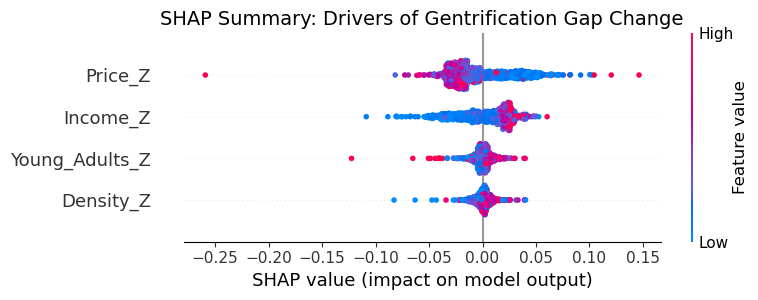

In [ ]:

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_full, show=False)
plt.title("SHAP Summary: Drivers of Gentrification Gap Change", fontsize=14)
plt.tight_layout()
plt.show()

### B. Feature Importance Bar Plot
A simpler view of the absolute importance of each feature.


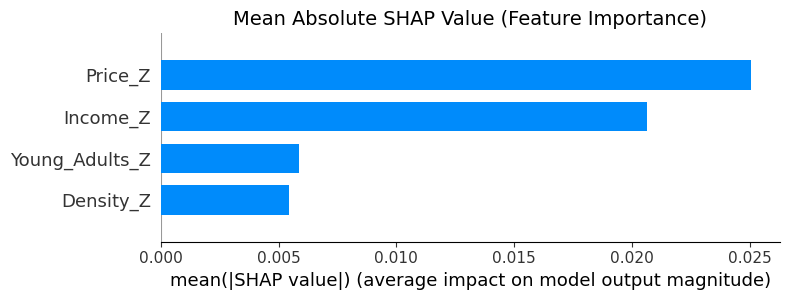

In [ ]:

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_full, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Value (Feature Importance)", fontsize=14)
plt.tight_layout()
plt.show()


### C. Dependence Plots (Interaction Effects)
Let's look at the top predictor (usually Price or Income) to see if the relationship is linear or if there are thresholds (e.g., does gentrification only accelerate after a certain density?).


Generating Dependence Plot for Top Feature: Price_Z


<Figure size 800x500 with 0 Axes>

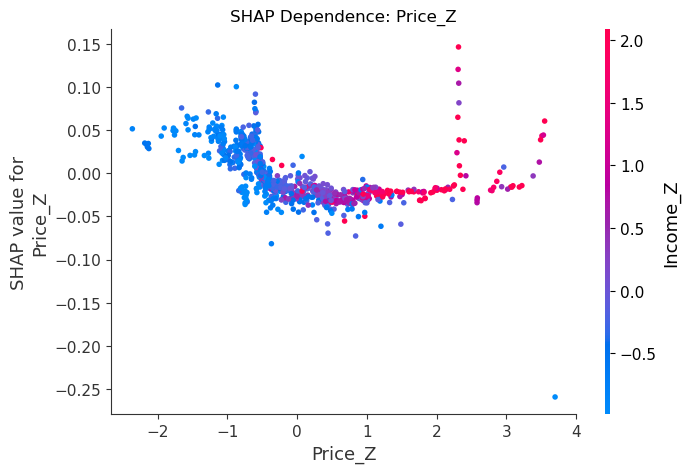

In [ ]:
# Find the most important feature index
mean_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_shap)
top_feature_name = features[top_feature_idx]

print(f"Generating Dependence Plot for Top Feature: {top_feature_name}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature_name, 
    shap_values, 
    X_full, 
    interaction_index="auto", # Automatically find the feature that interacts most
    show=False
)
plt.title(f"SHAP Dependence: {top_feature_name}", fontsize=12)
plt.show()


## 4. Temporal validation


### A. All cities together

In [ ]:
# --- TEMPORAL VALIDATION (Forecasting) ---
print("\n--- TEMPORAL VALIDATION: Train on Past, Predict Future ---")

# 1. Define Cutoff
# We train on "Starts" in 2015-2017, Test on "Starts" in 2018-2019
split_year = 2018 

train_time = model_df[model_df['Anno'] < split_year]
test_time = model_df[model_df['Anno'] >= split_year]

print(f"Training on years: {train_time['Anno'].unique()}")
print(f"Testing on years:  {test_time['Anno'].unique()}")
print(f"Train Size: {len(train_time)} | Test Size: {len(test_time)}")

# 2. Train & Predict
X_train_t = train_time[features]
y_train_t = train_time[target]
X_test_t = test_time[features]
y_test_t = test_time[target]
 
rf_time = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)
rf_time.fit(X_train_t, y_train_t)

# 3. Evaluate
y_pred_t = rf_time.predict(X_test_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
r2_t = r2_score(y_test_t, y_pred_t)

print(f"Temporal RMSE: {rmse_t:.4f}")
print(f"Temporal R2:   {r2_t:.4f}")

# 4. Map the Temporal Error (Crucial for Analysis)
# Which neighborhoods behaved "unexpectedly" in the most recent years?
test_time = test_time.copy()
test_time['Predicted_Gap_Change'] = y_pred_t
test_time['Error'] = test_time['Predicted_Gap_Change'] - test_time['Target_Delta_Gap']

# Save for QGIS
test_time.to_csv("../data/processed/temporal_predictions_2018_2019.csv", index=False)


--- TEMPORAL VALIDATION: Train on Past, Predict Future ---
Training on years: [2015. 2016. 2017.]
Testing on years:  [2018. 2019.]
Train Size: 553 | Test Size: 314
Temporal RMSE: 0.0855
Temporal R2:   0.1179


### B. One model per city (Barcelona and Milan)


--- Analyzing Barcelona ---
Barcelona Temporal R2: 0.3177
SHAP Explanation for Barcelona:


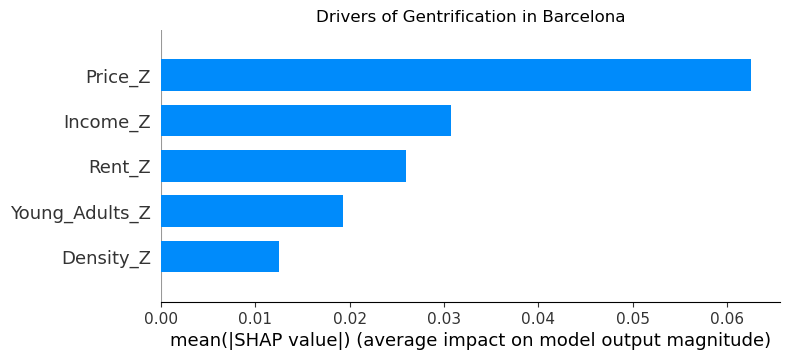

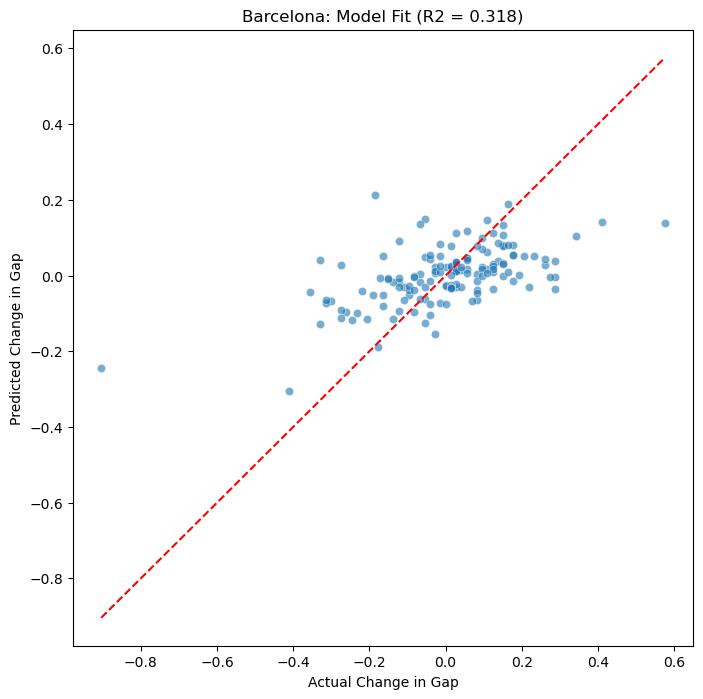

In [5]:
# --- FINAL VALIDATION: Per-City Temporal Split ---

# List of cities that have enough history   for temporal split
# (Paris is excluded because it only has one window)
cities_with_history = ['Barcelona'] # Only test with Barcelona for now

for city in cities_with_history:
    print(f"\n--- Analyzing {city} ---")
    
    # 1. Isolate City Data
    city_df = model_df[model_df['city'] == city].copy()
    
    # 2. Temporal Split (Train: < 2018, Test: >= 2018)
    train = city_df[city_df['Anno'] < 2018]
    test = city_df[city_df['Anno'] >= 2018]
    
    if len(test) == 0:
        print(f"Skipping {city} (No test data in 2018+)")
        continue
        
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # 3. Train Local Model
    rf_local = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf_local.fit(X_train, y_train)
    
    # 4. Evaluate
    y_pred = rf_local.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{city} Temporal R2: {r2:.4f}")
    
    # 5. Explain (SHAP) - What drives THIS city?
    # This is great for the report: "In BCN, Price matters most. In Milan, Density matters most?"
    explainer = shap.TreeExplainer(rf_local)
    shap_values = explainer.shap_values(X_train)
    print(f"SHAP Explanation for {city}:")
    
    plt.figure(figsize=(6, 4))
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title(f"Drivers of Gentrification in {city}")
    plt.show()
    
        # Run this after your Barcelona validation loop
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect fit line
    plt.xlabel("Actual Change in Gap")
    plt.ylabel("Predicted Change in Gap")
    plt.title(f"Barcelona: Model Fit (R2 = {r2:.3f})")
    plt.show()

## 5. Saving Predictions for Mapping
We save the predictions back to the dataframe so you can visualize the "Predicted vs Actual" gap in QGIS or GeoPandas.


In [ ]:
model_df['Predicted_Delta_Gap'] = final_model.predict(X_full)
model_df['Prediction_Error'] = model_df['Predicted_Delta_Gap'] - model_df['Target_Delta_Gap']

output_path = "../data/processed/model_predictions_shap.csv"
model_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

Predictions saved to ../data/processed/model_predictions_shap.csv
